In [1]:
import sys
import os
curr_dir=os.getcwd()
pardir=os.pardir
sys.path.append(os.path.join(curr_dir, pardir))
sys.path.append(os.path.join(curr_dir, pardir, pardir))
from liset_paper import liset_paper as liset_tk

import numpy as np
import matplotlib.pyplot as plt

from signal_aid import bandpass_filter
import matplotlib.pyplot as plt
# import seaborn as sns

In [12]:
parent=r"E:\neurospark_mat\Download_from_paper"
datasets=os.listdir(parent)
print("Available datasets:")
for i, dataset in enumerate(datasets):
    print(f"{i}: {dataset}")
print()
dataset=int(input("Dataset to process: "))
dataset_path=os.path.join(parent,datasets[dataset])


Available datasets:
0: Amigo2_2019-07-11_11-57-07
1: Dlx1_2021-02-12_12-46-54
2: Som2_2019-07-24_12-01-49
3: Thy7-2020-11-11_16-05-00



In [13]:
liset=liset=liset_tk(dataset_path, shank=1, downsample=False, start=0, verbose=False)
ripples=liset.ripples_GT


In [14]:
channel=1
window=[7,8] # in seconds
print(ripples[:10])
mask = (ripples[:, 1] >= window[0]*liset.fs) & (ripples[:, 0] <= window[1]*liset.fs)
window_ripples = ripples[mask]
print(f"Ripples in window {window}: {len(window_ripples)}")
channel_data = liset.data[:, channel]

[[  4814   6045]
 [  9033  10000]
 [ 12959  14804]
 [ 23271  24882]
 [ 85127  86266]
 [ 86318  87695]
 [ 90537  92412]
 [ 97187  98681]
 [106591 108291]
 [125181 126483]]
Ripples in window [7, 8]: 4


In [16]:
filtered_channel = bandpass_filter(channel_data, fs=liset.fs, bandpass=(100,250), order=4)
filtered_data = filtered_channel[window[0]*liset.fs:window[1]*liset.fs]

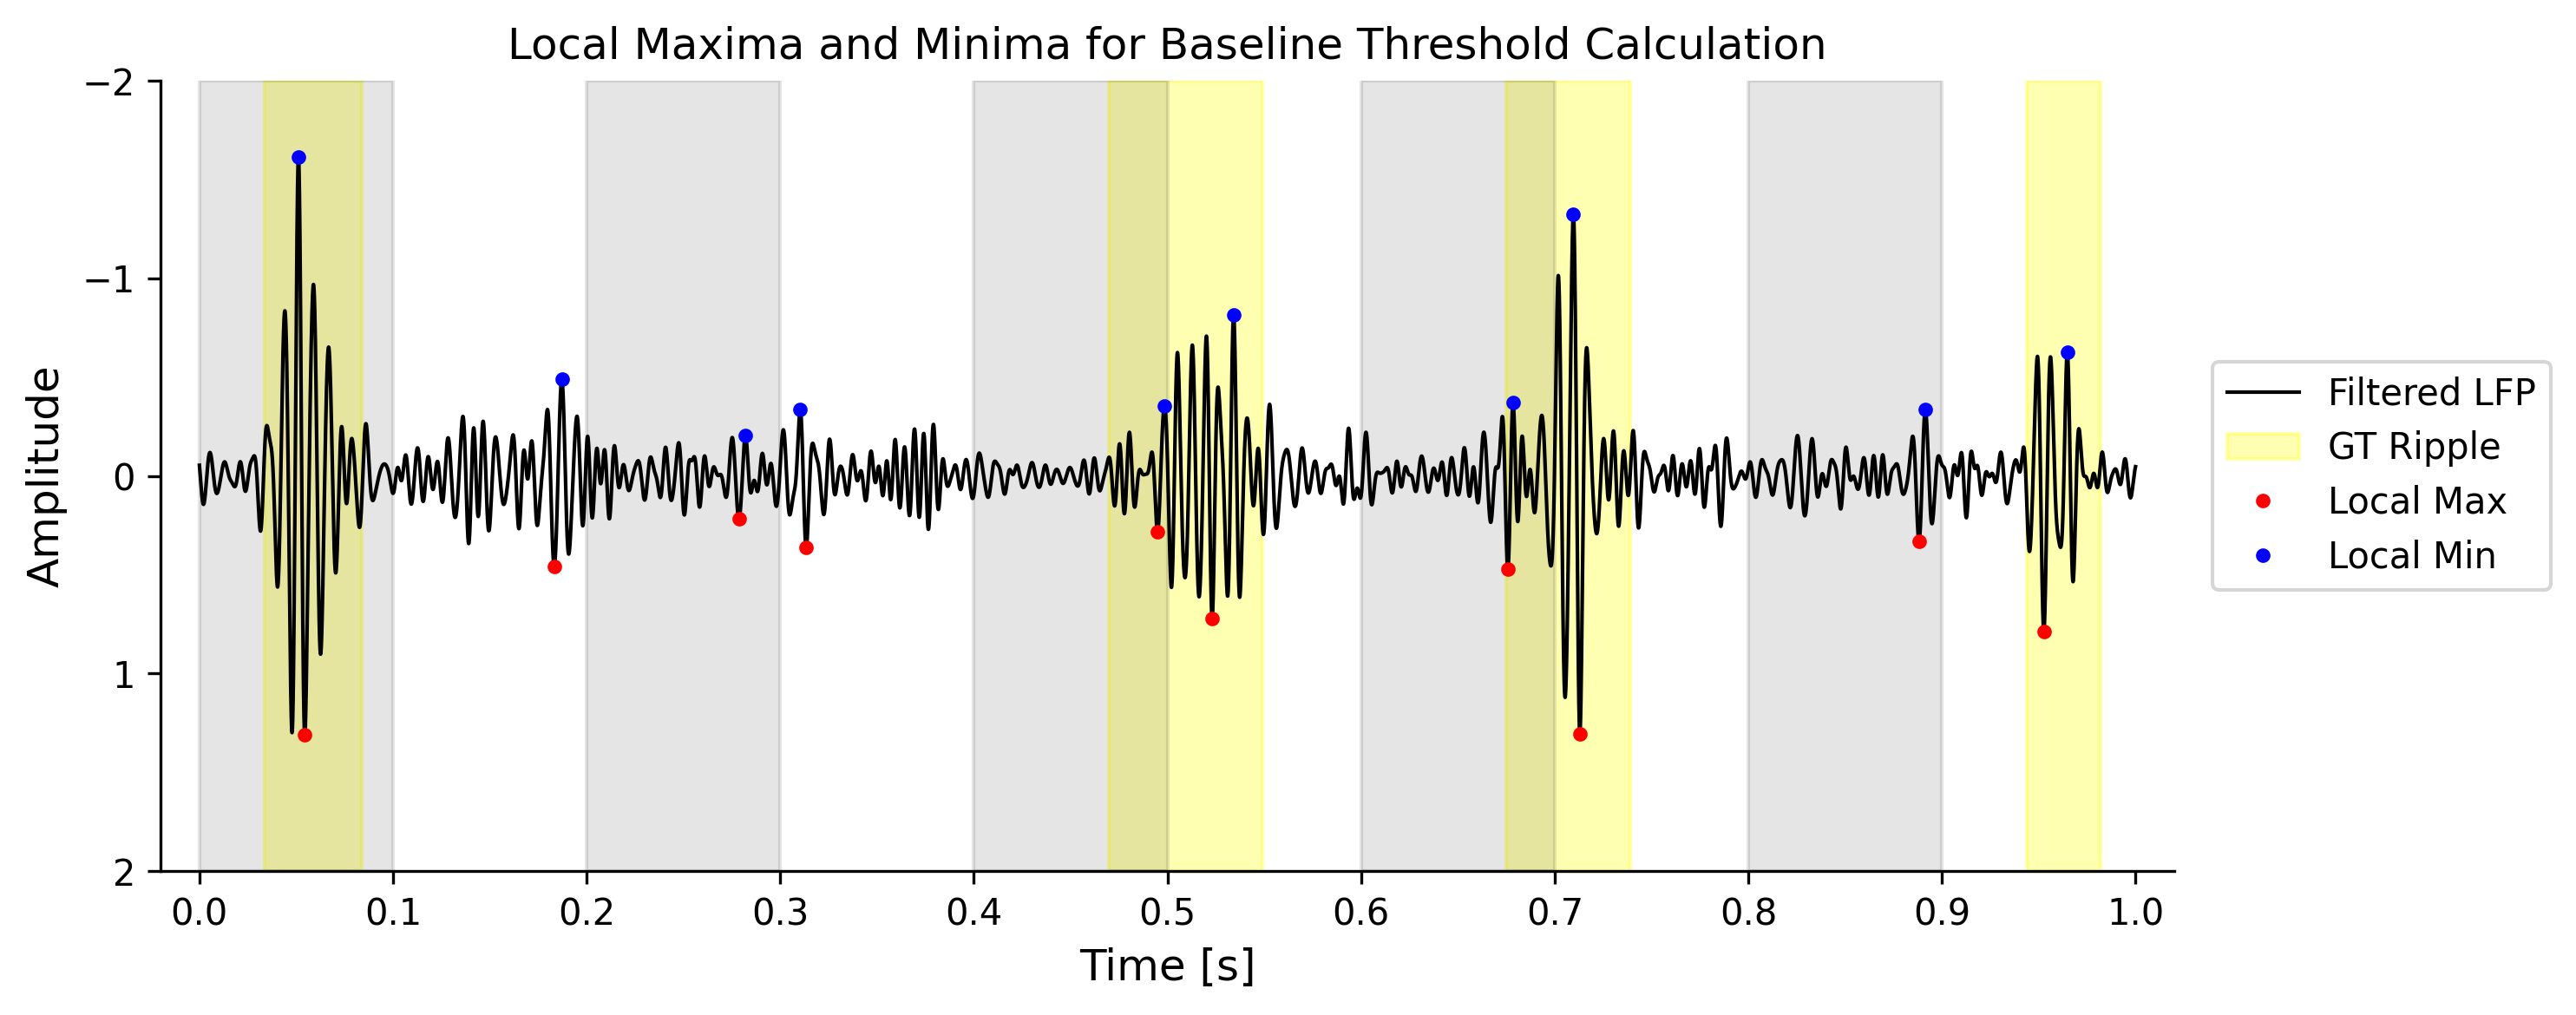

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

# Time axis starting from 0
time = np.arange(window[0]*liset.fs, window[1]*liset.fs) / liset.fs - window[0]
y_max,y_min=-2,2
# Plot filtered data
min_data, max_data = np.min(filtered_data), np.max(filtered_data)
ax.plot(time, filtered_data, label="Filtered LFP", color='black', linewidth=1)

# Highlight ripples
for i, ripple in enumerate(window_ripples):
    start, end = ripple / liset.fs - window[0]
    ax.fill_between([start, end],
                    y_min, y_max,
                    color="yellow", alpha=0.3,
                    label=f"GT Ripple" if i == 0 else None)

# Shaded 100ms intervals and max/min markers
step_sec = 0.1
step_samples = int(step_sec * liset.fs)
num_windows = int(len(filtered_data) / step_samples)

for i in range(num_windows):
    start_idx = i * step_samples
    end_idx = start_idx + step_samples
    if end_idx > len(filtered_data):
        break
    segment = filtered_data[start_idx:end_idx]
    segment_time = time[start_idx:end_idx]

    # Alternate box shading every other window
    if i % 2 == 0:
        ax.axvspan(segment_time[0], segment_time[-1], color='black', alpha=0.1)

    # Max/Min markers
    max_idx = np.argmax(segment)
    min_idx = np.argmin(segment)
    ax.plot(segment_time[max_idx], segment[max_idx], 'ro', markersize=3, label="Local Max" if i == 0 else "")
    ax.plot(segment_time[min_idx], segment[min_idx], 'bo', markersize=3, label="Local Min" if i == 0 else "")

# Final plot formatting
ax.set_xlabel("Time [s]",fontsize=12)
ax.set_ylabel("Amplitude",fontsize=12)
ax.set_title("Local Maxima and Minima for Baseline Threshold Calculation")
ax.set_xticks(np.arange(0, window[1] - window[0] + 0.1, 0.1))
# ax.set_yticks(np.arange(min_data * 1.2, max_data * 1.2, (max_data - min_data) / 5))
ax.set_xlim(-0.02, window[1] - window[0]+0.02)
ax.set_yticks([-2,-1, 0, 1, 2])
ax.set_ylim(y_min, y_max)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()


In [20]:
fig_path=os.path.join(os.getcwd(),"pngs", f"baseline_calculation.png")
fig.savefig(fig_path, dpi=300, bbox_inches='tight')